In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
%matplotlib inline

In [2]:
readFname = '../../WPWP_GLORYS_data/equator_sst_u_ssh_mld_2014_2024.nc'
fullDS = xr.open_dataset(readFname)

In [14]:
fullDS['sst_trend'] = (fullDS['sst'].roll(time=-1) - fullDS['sst'])
fullDS = fullDS.isel(time=slice(0,-1))

fullDS = fullDS.sel(longitude=slice(130,275))
fullDS = fullDS.interpolate_na(
    dim="longitude", method="linear"
).interpolate_na(
    dim="time", method="linear"
)

longitudes = fullDS['longitude'].to_numpy()
dates = fullDS['time'].to_numpy()


Text(0.5, 1.0, 'Zoanl Surf. Vel.')

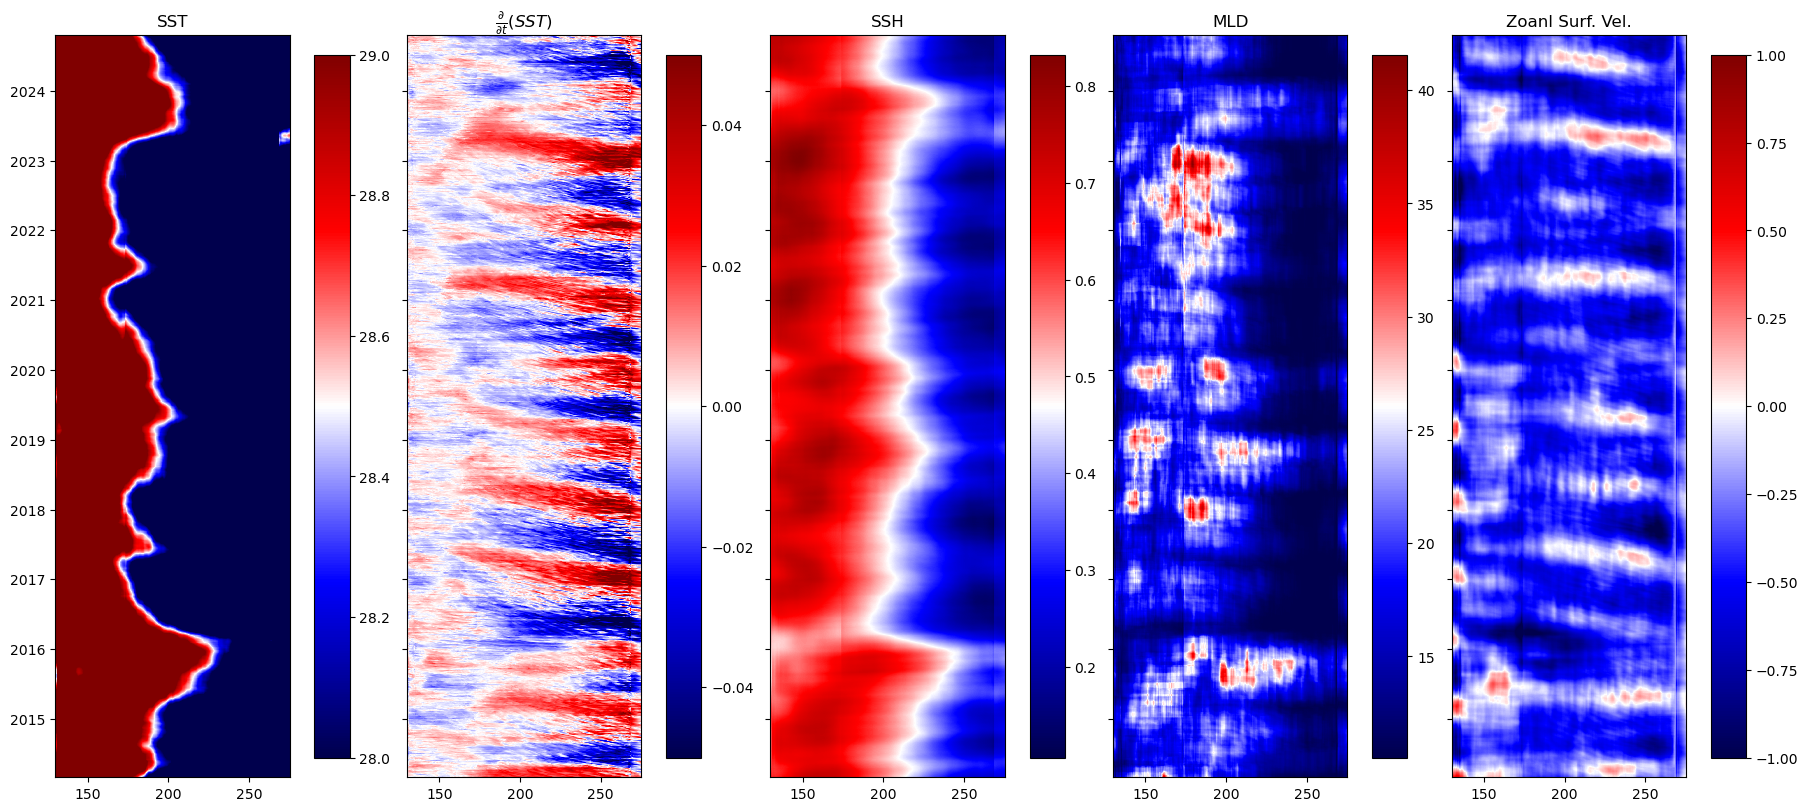

In [35]:
temp_trend = fullDS['sst_trend'].to_numpy()
temp = fullDS['sst'].to_numpy()

zos = fullDS['zos'].to_numpy()
mlotst = fullDS['mld'].to_numpy()
uo = fullDS['uo'].to_numpy()


klen = 121
hklen = int(klen//2)
kernel = np.ones((klen,1))
kernel /= np.sum(kernel)

dtT = convolve(temp_trend, kernel, mode='valid')
T = convolve(temp, kernel, mode='valid')

ssh = convolve(zos, kernel, mode='valid')
mld = convolve(mlotst, kernel, mode='valid')
uvel = convolve(uo, kernel, mode='valid')

fig, axes = plt.subplots(ncols=5, figsize=(18, 8), constrained_layout=True, sharey = True)
cmap = plt.cm.seismic

ax = axes[0]
vmin, vmax = 28, 29
titleStr = 'SST'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], T, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[1]
vmin, vmax = -0.05, 0.05
titleStr = r'$\frac{\partial}{\partial t} (SST)$'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], dtT, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[2]
vmin, vmax = -0.05, 0.05
titleStr = 'SSH'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], ssh ,cmap=cmap)#, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)


ax = axes[3]
vmin, vmax = -0.05, 0.05
titleStr = 'MLD'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], mld ,cmap=cmap)#, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[4]
vmin, vmax = -1, 1
titleStr = 'Zoanl Surf. Vel.'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], uvel ,cmap=cmap, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

Text(0.5, 1.0, 'Zoanl Surf. Vel.')

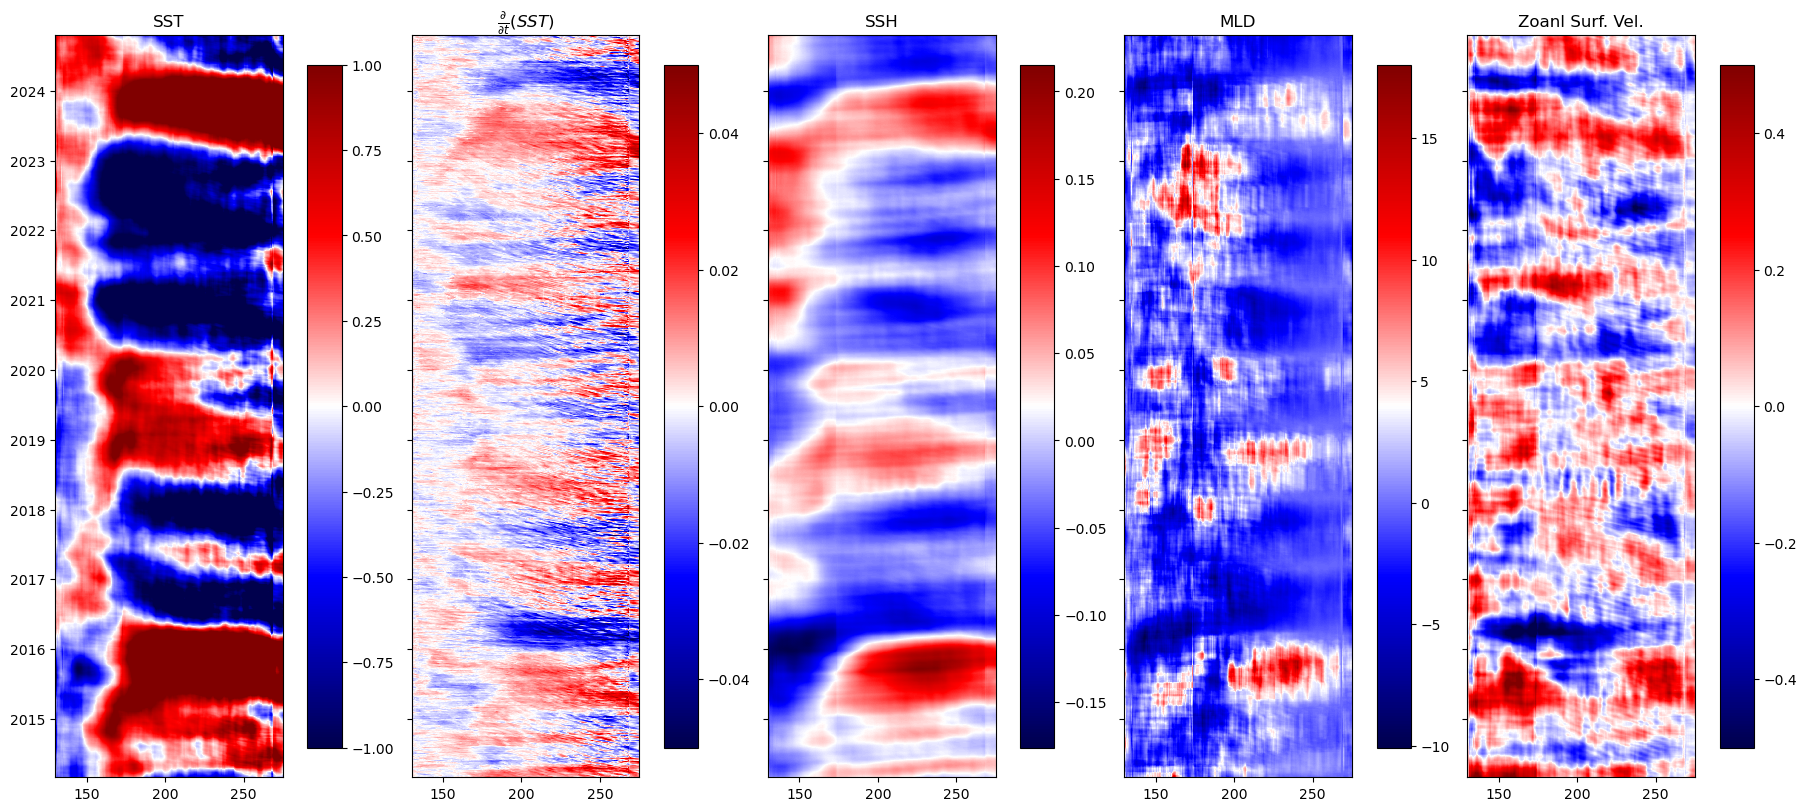

In [33]:
daily_climatology = fullDS.groupby('time.dayofyear').mean('time')
daily_anomalies = fullDS.groupby('time.dayofyear') - daily_climatology

temp_trend = daily_anomalies['sst_trend'].to_numpy()
temp = daily_anomalies['sst'].to_numpy()

zos = daily_anomalies['zos'].to_numpy()
mlotst = daily_anomalies['mld'].to_numpy()
uo = daily_anomalies['uo'].to_numpy()


klen = 121
hklen = int(klen//2)
kernel = np.ones((klen,1))
kernel /= np.sum(kernel)

dtT = convolve(temp_trend, kernel, mode='valid')
T = convolve(temp, kernel, mode='valid')

ssh = convolve(zos, kernel, mode='valid')
mld = convolve(mlotst, kernel, mode='valid')
uvel = convolve(uo, kernel, mode='valid')

fig, axes = plt.subplots(ncols=5, figsize=(18, 8), constrained_layout=True, sharey = True)
cmap = plt.cm.seismic

ax = axes[0]
vmin, vmax = -1,1
titleStr = 'SST'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], T, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[1]
vmin, vmax = -0.05, 0.05
titleStr = r'$\frac{\partial}{\partial t} (SST)$'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], dtT, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[2]
vmin, vmax = -0.05, 0.05
titleStr = 'SSH'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], ssh ,cmap=cmap)#, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)


ax = axes[3]
vmin, vmax = -0.05, 0.05
titleStr = 'MLD'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], mld ,cmap=cmap)#, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)

ax = axes[4]
vmin, vmax = -0.5, 0.5
titleStr = 'Zoanl Surf. Vel.'
pmesh = ax.pcolormesh(longitudes, dates[hklen:-hklen], uvel ,cmap=cmap, vmin=vmin, vmax=vmax,  shading='auto')
plt.colorbar(pmesh, ax= ax)
ax.set_title(titleStr)